In [1]:
import math
import numpy as np
import cmath as cm
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# --- objective Ex 4.2 (real) ---
def f(x):
    return (x[0] - x[1])**2 + (x[0]*(1-x[0]))**2 + (x[1]*(2-x[1]))**2

def grad_f(x):
    return np.array([4*x[0]**3 - 6*x[0]**2 +4*x[0] - 2*x[1], 4*x[1]**3 - 12*x[1]**2 + 10*x[1] - 2*x[0] ])
    
def hess_f(x):
    return np.array([
        [12*x[0]**2 - 12*x[0] + 4 , -2 ],
        [-2 , 12*x[1]**2 - 24*x[1] + 10 ]
    ])


# --- same objective, complex arguments z in C^n (for the Mixed Newton method) ---
def f_comp(z): # z \in C^2
    return (z[0] - z[1])**2 + (z[0]*(1-z[0]))**2 + (z[1]*(2-z[1]))**2

def grad_f_comp(z):
    return np.array([4*z[0]**3 - 6*z[0]**2 +4*z[0] - 2*z[1], 4*z[1]**3 - 12*z[1]**2 + 10*z[1] - 2*z[0] ])


# --- target critical points to classify convergence against ---
#     'point'  : the (real) critical point
#     'color'  : colour of its basin in the plot
#     'marker' : colour of the point's own marker
TARGETS = [
    {'label': 'local min 1', 'point': np.array([1.27473, 1.81735]),'color': 'cyan', 'marker': 'red'},
    {'label': 'global min',  'point': np.array([0.0, 0.0]), 'color': 'y', 'marker': 'black'},
    {'label': 'saddle point','point': np.array([1.0, 1.0]), 'color': 'blue', 'marker': 'magenta'},
]

for t in TARGETS:
    print('f(%-12s) = %.10f' % (t['label'], f(t['point'])))

# --- grid of initial points ---
a_1, b_1 = -1, 3      # x-range
a_2, b_2 = -1, 3      # y-range
h_  = 0.13            # grid step
d_  = 0.0             # imaginary part of every complex initial coordinate
PLOT_BOX = [a_1, b_1, a_2, b_2]

# --- solver parameters ---
R        = 1000.0     # divergence radius
dist     = 1e-5       # convergence tolerance to a target
gamma    = 1e-3       # gamma used by the single run in section 4
max_iter = 10**6      # iteration cap  ("not converged after 1e6 iterations")
STAG_TOL = 1e-13      # step norm below which a trajectory is treated as settled
IMAG_CAP = 350.0      # |Im z| beyond this overflows cosh/sinh in float64 -> divergence

f(local min 1 ) = 0.5272645929
f(global min  ) = 0.0000000000
f(saddle point) = 1.0000000000


In [3]:
def make_grid_real(a1, b1, a2, b2, h):
    return [np.array([s, t]) for s in np.arange(a1, b1 + h, h)
                             for t in np.arange(a2, b2 + h, h)]

def make_grid_complex(a1, b1, a2, b2, h, d):
    return [np.array([s + d*1j, t + d*1j]) for s in np.arange(a1, b1 + h, h)
                                           for t in np.arange(a2, b2 + h, h)]

def _empty(targets):
    r = {t['label']: [] for t in targets}
    r['divergence'] = []; r['not_converged'] = []
    return r


def run_ordinary_newton(f, grad_f, hess_f, initial_points, targets,
                        R, dist, max_iter=10**6, stag_tol=1e-13):
    """Newton on phi(x) = 1/2 f(x)^2:
         x <- x - ( grad f grad f^T + f Hess f )^{-1} ( f grad f ).
    Returns {target_label: [starts], 'divergence': [...], 'not_converged': [...]}."""
    res    = _empty(targets)
    tpts   = [np.asarray(t['point'], dtype=float) for t in targets]
    labels = [t['label'] for t in targets]
    R2, dist2, stag2 = R*R, dist*dist, stag_tol*stag_tol
    for x0 in initial_points:
        x = np.asarray(x0, dtype=float); k = 0; bucket = 'not_converged'
        while True:
            hit = False
            for lbl, tp in zip(labels, tpts):
                d = x - tp
                if d.dot(d) <= dist2:
                    bucket = lbl; hit = True; break
            if hit: break
            if x.dot(x) >= R2:     bucket = 'divergence';    break
            if k >= max_iter:      bucket = 'not_converged'; break
            fx = f(x); g = grad_f(x)
            A  = np.outer(g, g) + fx*hess_f(x)
            dz = np.linalg.solve(A, fx*g)
            x  = x - dz; k += 1
            if dz.dot(dz) < stag2: bucket = 'not_converged'; break   # settled off-target
        res[bucket].append(np.asarray(x0))
    return res


def run_mixed_newton(f_comp, grad_f_comp, initial_points, targets, gamma,
                     R, dist, max_iter=10**6, stag_tol=1e-13, imag_cap=350.0):
    """Regularized Mixed Newton method in C^n, VECTORIZED over all initial points:
         z <- z - ( conj(grad) grad^T + 2 g^2 diag(cosh 2Im z) )^{-1}
                  ( f conj(grad) + 2 i g^2 sinh 2Im z ).
    `imag_cap` guards cosh/sinh from float64 overflow (a blown-up imaginary part
    is treated as divergence).  Same classification as the point-by-point version."""
    Z0 = np.array(initial_points, dtype=complex).T            # (n, m)
    n, m = Z0.shape
    tp   = np.array([np.asarray(t['point'], dtype=complex) for t in targets])   # (T, n)
    T    = len(targets); DIV, NC = T, T + 1
    outcome = np.full(m, -1, dtype=int)
    order   = np.arange(m)
    Z  = Z0.copy(); kk = np.zeros(m, dtype=np.int64)
    R2, dist2, stag2, g2 = R*R, dist*dist, stag_tol*stag_tol, gamma*gamma
    diag = np.arange(n)
    while Z.shape[1] > 0:
        # (a) convergence to the first target within `dist`
        diff = Z.T[None, :, :] - tp[:, None, :]               # (T, ma, n)
        d2   = (diff.real**2 + diff.imag**2).sum(axis=2)      # (T, ma)
        any_conv = d2.min(axis=0) <= dist2
        code = np.where(any_conv, np.argmax(d2 <= dist2, axis=0), -1)
        done = any_conv.copy()
        # (b) divergence by norm
        normZ2 = (Z.real**2 + Z.imag**2).sum(axis=0)
        mask = (~done) & (normZ2 >= R2); code[mask] = DIV; done |= mask
        # (c) overflow / imag-cap divergence  (before any cosh/sinh)
        mask = (~done) & (np.abs(Z.imag).max(axis=0) >= imag_cap); code[mask] = DIV; done |= mask
        # (d) iteration cap
        mask = (~done) & (kk >= max_iter); code[mask] = NC; done |= mask
        if done.any():
            outcome[order[done]] = code[done]
            keep = ~done; Z = Z[:, keep]; order = order[keep]; kk = kk[keep]
            if Z.shape[1] == 0: break
        # (e) one vectorized Newton step
        g  = grad_f_comp(Z)                                   # (n, ma)
        im = Z.imag
        A  = np.conj(g)[:, None, :] * g[None, :, :]           # (n, n, ma) = outer(conj g, g)
        A[diag, diag, :] += 2*g2*np.cosh(2*im)                # + 2 g^2 diag(cosh)
        rhs = f_comp(Z)*np.conj(g) + 2j*g2*np.sinh(2*im)      # (n, ma)
        dz  = np.linalg.solve(A.transpose(2, 0, 1), rhs.T[:, :, None])[:, :, 0].T
        Z   = Z - dz; kk = kk + 1
        # (f) stagnation -> not converged
        stag = (dz.real**2 + dz.imag**2).sum(axis=0) < stag2
        if stag.any():
            outcome[order[stag]] = NC
            keep = ~stag; Z = Z[:, keep]; order = order[keep]; kk = kk[keep]
    names = [t['label'] for t in targets] + ['divergence', 'not_converged']
    res = _empty(targets)
    for col in range(m):
        res[names[outcome[col]]].append(np.asarray(initial_points[col]))
    return res


def report(title, result, n_total):
    print(title)
    conv = 0
    for lbl in [k for k in result if k not in ('divergence', 'not_converged')]:
        print('   convergence to %-13s = %d' % (lbl, len(result[lbl]))); conv += len(result[lbl])
    print('   divergence                  = %d' % len(result['divergence']))
    print('   not converged (<= max_iter) = %d' % len(result['not_converged']))
    print('   total = %d  (grid = %d)' %
          (conv + len(result['divergence']) + len(result['not_converged']), n_total))


def sweep_gamma(f_comp, grad_f_comp, initial_points, targets, gammas,
                R, dist, max_iter=10**6, stag_tol=1e-13, imag_cap=350.0):
    """Run the (vectorized) Mixed Newton method for each gamma in `gammas`.
    Prints one summary row per gamma and returns {gamma: result_dict}."""
    out = {}
    head = 'gamma'.rjust(8) + ''.join(t['label'].rjust(14) for t in targets) \
           + 'diverg.'.rjust(10) + 'not_conv'.rjust(10) + 'time[s]'.rjust(9)
    print(head); print('-'*len(head))
    for g in gammas:
        t0 = datetime.now()
        r  = run_mixed_newton(f_comp, grad_f_comp, initial_points, targets, g,
                              R, dist, max_iter, stag_tol, imag_cap)
        dt = (datetime.now() - t0).total_seconds()
        out[g] = r
        row = ('%.4g' % g).rjust(8) + ''.join(('%d' % len(r[t['label']])).rjust(14) for t in targets) \
              + ('%d' % len(r['divergence'])).rjust(10) + ('%d' % len(r['not_converged'])).rjust(10) \
              + ('%.2f' % dt).rjust(9)
        print(row)
    return out


def plot_basins(result, targets, box, title=''):
    plt.figure(figsize=(10, 8)); plt.axis(box)
    for t in targets:
        pts = result[t['label']]
        if pts:
            plt.scatter([p[0].real for p in pts], [p[1].real for p in pts],
                        s=10, color=t['color'], label='conv. to ' + t['label'])
    for key, col in (('divergence', 'orange'), ('not_converged', 'brown')):
        pts = result[key]
        if pts:
            plt.scatter([p[0].real for p in pts], [p[1].real for p in pts],
                        s=10, color=col, label=key.replace('_', ' '))
    for t in targets:
        p = np.asarray(t['point']).real
        plt.scatter([p[0]], [p[1]], color=t['marker'], edgecolor='k', zorder=5, label=t['label'])
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.07), fancybox=True, shadow=True, ncol=4)
    if title: plt.title(title)
    plt.show()


def plot_gamma_summary(results_by_gamma, targets, n_total):
    gs = sorted(results_by_gamma)
    plt.figure(figsize=(10, 6))
    for t in targets:
        plt.plot(gs, [len(results_by_gamma[g][t['label']]) for g in gs],
                 marker='o', color=t['color'], label='conv. to ' + t['label'])
    plt.plot(gs, [len(results_by_gamma[g]['not_converged']) for g in gs],
             marker='s', color='brown', label='not converged')
    plt.plot(gs, [len(results_by_gamma[g]['divergence']) for g in gs],
             marker='^', color='orange', label='divergence')
    plt.xlabel('gamma'); plt.ylabel('number of initial points (of %d)' % n_total)
    plt.title('Mixed Newton method: convergence outcome vs gamma')
    plt.grid(True, alpha=0.3); plt.legend(loc='best'); plt.show()


Initial_points_reals   = make_grid_real(a_1, b_1, a_2, b_2, h_)
Initial_points_complex = make_grid_complex(a_1, b_1, a_2, b_2, h_, d_)
print('real initial points    =', len(Initial_points_reals))
print('complex initial points =', len(Initial_points_complex))

real initial points    = 1024
complex initial points = 1024


## Ordinary Newton method

Time (seconds)= 1.022265
Ordinary Newton method
   convergence to local min 1   = 443
   convergence to global min    = 463
   convergence to saddle point  = 117
   divergence                  = 1
   not converged (<= max_iter) = 0
   total = 1024  (grid = 1024)


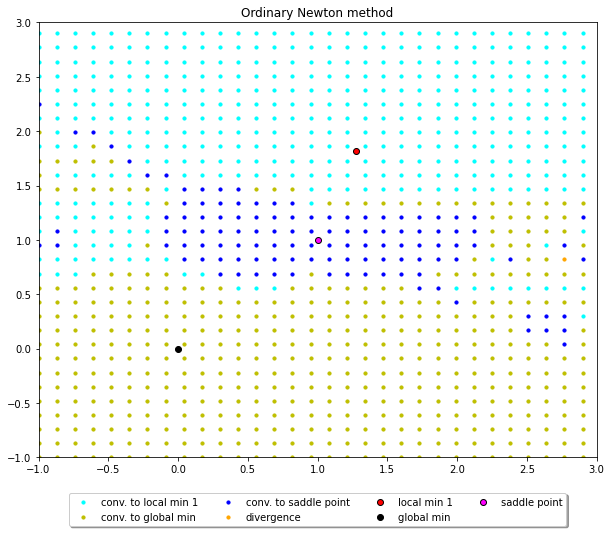

In [4]:
start_time = datetime.now()
res_ON = run_ordinary_newton(f, grad_f, hess_f,
                             Initial_points_reals, TARGETS,
                             R, dist, max_iter=max_iter, stag_tol=STAG_TOL)
print('Time (seconds)=', (datetime.now() - start_time).total_seconds())
report('Ordinary Newton method', res_ON, len(Initial_points_reals))
plot_basins(res_ON, TARGETS, PLOT_BOX, title='Ordinary Newton method')

## Mixed Newton method over a range of gamma

In [5]:
# Runs the Mixed Newton method for every gamma in GAMMA_VALUES,
# prints a summary table, and plots the outcome counts as a function of gamma.

# --- gamma values to test in the Mixed Newton sweep ---
GAMMA_VALUES = [1e-3, 1e-2, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.2, 1.4, 1.5, 1.7, 1.9, 2.0, 2.5, 3.0, 4.0, 5.0]

results_by_gamma = sweep_gamma(f_comp, grad_f_comp, Initial_points_complex, TARGETS, GAMMA_VALUES,
                               R, dist, max_iter=max_iter, stag_tol=STAG_TOL, imag_cap=IMAG_CAP)

   gamma   local min 1    global min  saddle point   diverg.  not_conv  time[s]
-------------------------------------------------------------------------------
   0.001             0          1024             0         0         0     1.26
    0.01             0          1024             0         0         0   115.59
     0.1             0             0             0         0      1024   571.05
     0.2             0             0             0         0      1024   537.46
     0.3             1             0             0         0      1023   583.48
     0.4             0             0             0         0      1024   585.00
     0.5             0             0             0         0      1024   555.17
       1             0             0             0         0      1024   538.42
     1.2           483             0             0         0       541   417.60
     1.4           484             0             0         0       540   410.16
     1.5           484             0    

In [6]:
#plot_gamma_summary(results_by_gamma, TARGETS, len(Initial_points_complex))

In [7]:
### Basin plot for each gamma in the sweep.
# for g in GAMMA_VALUES:
#     plot_basins(results_by_gamma[g], TARGETS, PLOT_BOX, title='Mixed Newton method,  gamma = %g' % g)